# Tutorial: Maximum Entropy Snapshot Sampling (MESS) for Data Compression
This notebook demonstrates the **Maximum Entropy Snapshot Sampling** (MESS) as a preprocessing method for data compression, where representative snapshots are selected by greedily maximizing the $\varepsilon$-Frobenius entropy to retain maximal information content.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time

from PIL import Image
from mess import MESS

In [2]:
img = Image.open("data/flowers.jpg").convert("L")  # "L" = grayscale
img_array = np.array(img)

In [3]:
mess = MESS(img_array)
data_sampled = mess.sampling(eps=0.2)

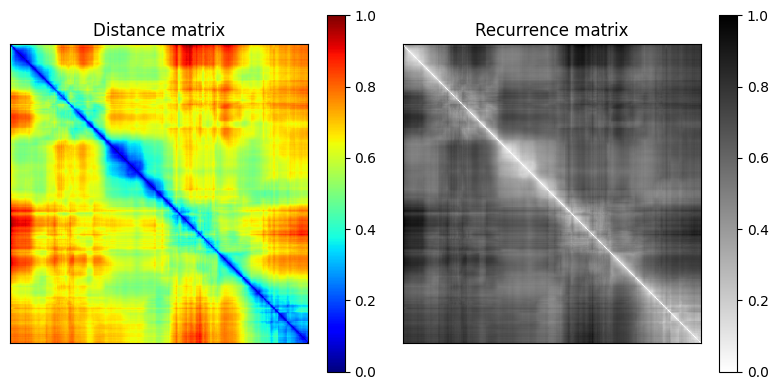

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sp1 = axes[0].pcolor(mess.state_matrix, cmap='jet')
sp2 = axes[1].pcolor(mess.state_matrix, cmap='binary')

fig.colorbar(sp1, ax=axes[0])
fig.colorbar(sp2, ax=axes[1])

axes[0].set_title("Distance matrix")
axes[1].set_title("Recurrence matrix")

axes[0].invert_yaxis()
axes[1].invert_yaxis()


axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].set_xticks([])
axes[1].set_yticks([])

axes[0].set_aspect('equal')
axes[1].set_aspect('equal')

plt.tight_layout()

In [5]:
time_mess = time.time()
u_mess, _, _ = np.linalg.svd(data_sampled)
time_mess = time.time()-time_mess

time_svd = time.time()
u_svd, _, _ = np.linalg.svd(img_array)
time_svd = time.time()-time_svd

In [ ]:
print("SVD vs. MESS (SVD) Comparison")
print("-" * 36)
print(f"{'Method':<20} {'Time [s]':<10}")
print("-" * 36)
print(f"{'SVD':<20} {time_svd:<10.2f}")
print(f"{'MESS (SVD)':<20} {time_mess:<10.2f}")

SVD vs. MESS (SVD) Comparison
------------------------------------
Method               Time [s]  
------------------------------------
SVD                  3.96      
MESS + SVD           0.47      


In [7]:
img_array_svd = (u_svd[:, 0:data_sampled.shape[1]]) @ (u_svd[:, 0:data_sampled.shape[1]].T) @ img_array
img_array_mess = (u_mess[:, 0:data_sampled.shape[1]]) @ (u_mess[:, 0:data_sampled.shape[1]].T) @ img_array

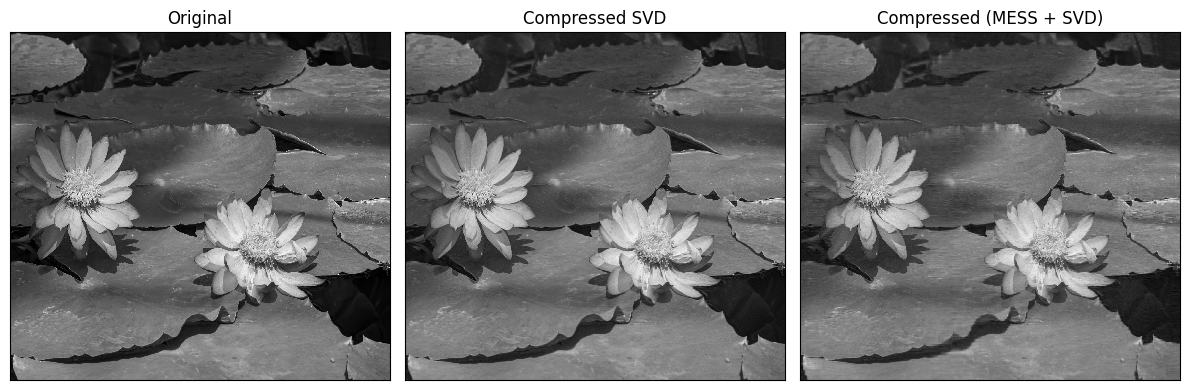

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].pcolor(img_array, cmap='gray')
axes[1].pcolor(img_array_svd, cmap='gray')
axes[2].pcolor(img_array_mess, cmap='gray')

axes[0].set_title("Original")
axes[1].set_title("Compressed SVD")
axes[2].set_title("Compressed (MESS + SVD)")

axes[0].invert_yaxis()
axes[1].invert_yaxis()
axes[2].invert_yaxis()

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()